In [1]:
import corner
import datetime as dt 
import logging
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import ocnus_py
from ocnus_py import ECHModel, ECHMagFilter, Obs, Univariate, ObsVecNoise

logging.basicConfig(format='%(levelname)s %(filename)s:%(lineno)d %(asctime)-15s %(message)s')
logging.getLogger().setLevel(logging.INFO)

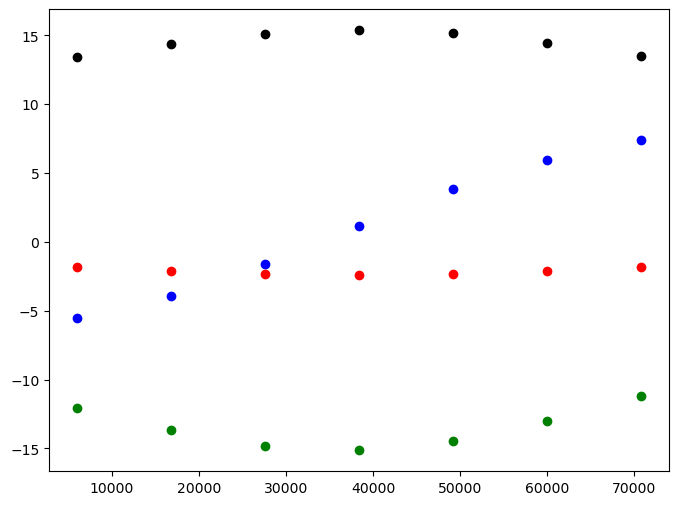

In [2]:
# Set up model priors
model = ECHModel([
    Univariate.uniform("phi", -1.0, 1.0),
    # Univariate.constant("phi", -0.22),
    # Univariate.uniform("theta", np.pi - 1.25, np.pi + 1.25),
    Univariate.constant("theta", 3.06),
    Univariate.constant("psi", 0.0),
    # Univariate.constant("y", -0.11),
    Univariate.uniform("y_0", -0.65, 0.65),
    Univariate.constant("cs_delta", 1.0),
    Univariate.constant("radius", 0.11),
    Univariate.constant("x_0", 0.87),
    # Univariate.uniform("x_0", 0.25, 1.0),
    Univariate.constant("speed", 500.0),
    Univariate.uniform("b_scale", 10, 25),
    Univariate.constant("lambda", 0.0),
    Univariate.constant("alpha", 0.0),
    Univariate.constant("tau", 5.2),
])

params = np.array([[-0.22, 3.06, 0.0, -0.11, 1.0, 0.11, 0.87, 500.0, 15.4, 0.0, 0.0, 5.2]])

noise_std = 0.1
sc_count = 7
N = 2048

# observations without observations
obs = Obs(
    [6000 + i * 3600 * (18 / (sc_count - 1)) for i in range(sc_count)],
    np.array([[1.0, 0.0, 0.0] for _ in range(sc_count)])
)

covmat = noise_std ** 2 * np.eye(obs.count())

# assert that all points are within the fr (and not NaN)
diag = model.icsbasis(obs, params)
assert np.all(diag.get(0)[0][:, 0] < 1.0)

output = model.simulate_mag(obs, params).get(0)

plt.figure(figsize=(8, 6))
plt.scatter(obs.timestamps(), np.sqrt(np.sum(output**2, axis=1)), color="k")
plt.scatter(obs.timestamps(), output[:, 0], color="r")
plt.scatter(obs.timestamps(), output[:, 1], color="g")
plt.scatter(obs.timestamps(), output[:, 2], color="b")

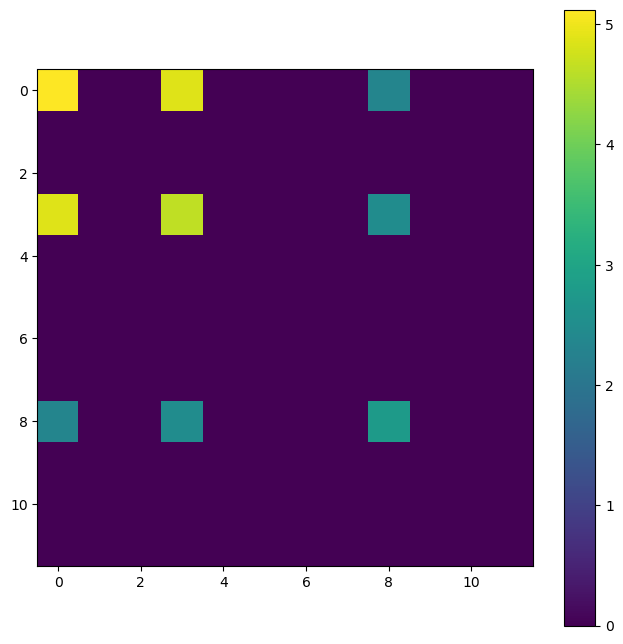

In [3]:
fisher = model.fisher_mag(obs, params[0], covmat)
plt.figure(figsize=(8, 8))
plt.imshow(np.log10(np.abs(fisher) + 1), interpolation= None)
plt.colorbar()
plt.show()

In [4]:
filter = model.new_mag_filter(obs, output, 2048, 42)
filter.initialize(metric='nrmse', threshold=1.0)

particles_init = filter.particles()

In [ ]:
filter_abc = filter.copy()

noise = ObsVecNoise.additive_normal(std_dev=noise_std)

for threshold in [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.25, 0.2, 0.175, 0.15]:
    ess = filter_abc.abc_mvnk(metric='nrmse', threshold=threshold, noise=noise)
    print("Filtering with threshold {}, effective sample size: {:.1f}".format(threshold, ess))

print("ABC Mean: {:.3f}".format(np.mean(filter_abc.errors())))
print("ABC Minimum: {:.3f}".format(np.min(filter_abc.errors())))

particles_abc = filter_abc.particles()

Filtering with threshold 0.9, effective sample size: 1809.7
Filtering with threshold 0.8, effective sample size: 1874.6
Filtering with threshold 0.7, effective sample size: 1870.7
Filtering with threshold 0.6, effective sample size: 1897.9
Filtering with threshold 0.5, effective sample size: 1909.1
Filtering with threshold 0.4, effective sample size: 1924.7
Filtering with threshold 0.3, effective sample size: 1933.4
Filtering with threshold 0.25, effective sample size: 1925.7
Filtering with threshold 0.2, effective sample size: 1941.6
Filtering with threshold 0.175, effective sample size: 1917.7
Filtering with threshold 0.15, effective sample size: 1929.7
ABC Mean: 0.096
ABC Minimum: 0.003


In [6]:
filter_dev = filter.copy()

mutation_counter = 0

for i in range(800):
    mutation_counter += filter_dev.dev(metric='nchisq', mutation_factor=0.1, recombination_factor=0.8)

    if i > 0 and i % 100 == 0:
        print("Last 100 iterations: {} mutations".format(mutation_counter))
        mutation_counter = 0

print("DEV Minimum: {:.3f}".format(np.min(filter_dev.errors())))

particles_dev = filter_dev.particles()

dev_min = particles_dev[0][np.argmin(filter_dev.errors())]

Last 100 iterations: 31966 mutations
Last 100 iterations: 10205 mutations
Last 100 iterations: 3872 mutations
Last 100 iterations: 1755 mutations
Last 100 iterations: 2113 mutations
Last 100 iterations: 1140 mutations
Last 100 iterations: 996 mutations
DEV Minimum: 0.000


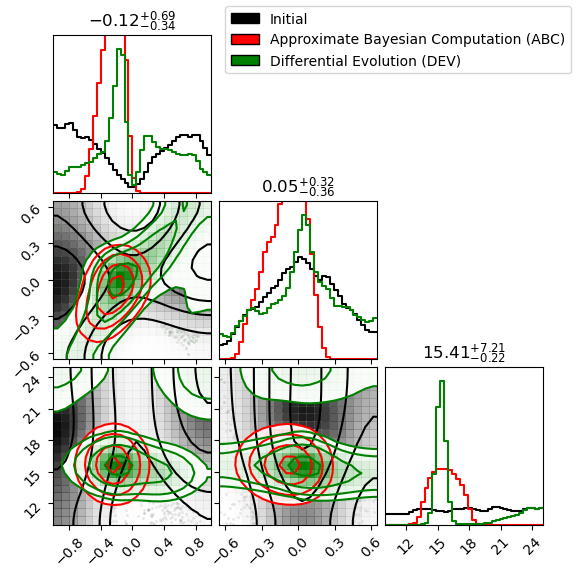

In [8]:
autorange = np.array([np.min(particles_init[0], axis=0), np.max(particles_init[0], axis=0)]).T
autoflag = [True for _ in autorange]

for idx in range(len(autorange)):
        if autorange[idx][0] == autorange[idx][1]:
                autoflag[idx] = False

cfig = plt.figure(figsize=(6, 6))
corner.corner(particles_init[0].T[autoflag].T, 
              weights=np.ones_like(particles_abc[1]) / 2048, color='k',
              range=autorange[autoflag], fig=cfig, smooth=5.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2)
corner.corner(particles_abc[0].T[autoflag].T, 
              weights=particles_abc[1], color='r',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
corner.corner(particles_dev[0].T[autoflag].T, 
              weights=np.ones_like(particles_abc[1]) / 2048, color='g',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
cfig.legend(handles=[
    Patch(facecolor='k', edgecolor='k', label="Initial"),
    Patch(facecolor='r', edgecolor='k', label="Approximate Bayesian Computation (ABC)"),
    Patch(facecolor='g', edgecolor='k', label="Differential Evolution (DEV)"),
], loc='upper right')
plt.show()

In [9]:
filter_sir = filter_abc.copy()

for i in [5, 4, 3, 2, 1.5, 1, 1, 1]:
    (ess, us) = filter_sir.sir_mvnk(i * noise_std**2 * np.eye(7))
    print("SIR Filtering with covariance scale {}, effective sample size: {:.1f}, unique samples {}".format(i, ess, us))

particles_sir = filter_sir.particles()

SIR Filtering with covariance scale 5, effective sample size: 20.0, unique samples 88
SIR Filtering with covariance scale 4, effective sample size: 7026.3, unique samples 1786
SIR Filtering with covariance scale 3, effective sample size: 5388.1, unique samples 1730
SIR Filtering with covariance scale 2, effective sample size: 4628.5, unique samples 1657
SIR Filtering with covariance scale 1.5, effective sample size: 4729.5, unique samples 1678
SIR Filtering with covariance scale 1, effective sample size: 3747.7, unique samples 1614
SIR Filtering with covariance scale 1, effective sample size: 7200.3, unique samples 1767
SIR Filtering with covariance scale 1, effective sample size: 6244.7, unique samples 1753


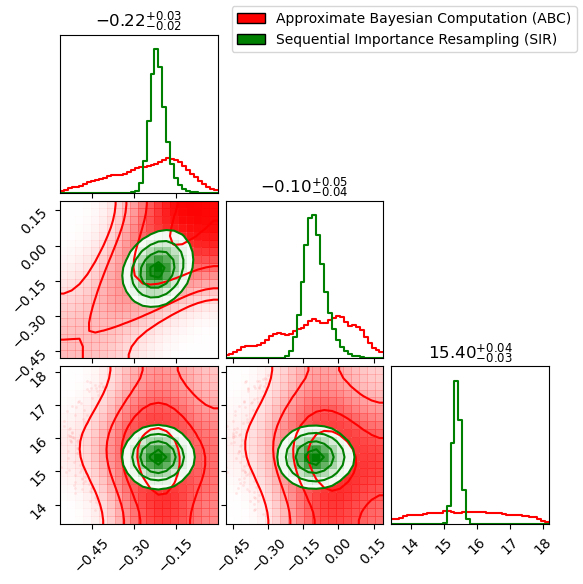

In [10]:
autorange = np.array([np.min(particles_abc[0], axis=0), np.max(particles_abc[0], axis=0)]).T
autoflag = [True for _ in autorange]

for idx in range(len(autorange)):
        if autorange[idx][0] == autorange[idx][1]:
                autoflag[idx] = False

cfig = plt.figure(figsize=(6, 6))
corner.corner(particles_abc[0].T[autoflag].T, 
              weights=particles_abc[1], color='r',
              range=autorange[autoflag], fig=cfig, smooth=5.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2)
corner.corner(particles_sir[0].T[autoflag].T, 
              weights=np.ones_like(particles_abc[1]) / 2048, color='g',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
cfig.legend(handles=[
    Patch(facecolor='r', edgecolor='k', label="Approximate Bayesian Computation (ABC)"),
    Patch(facecolor='g', edgecolor='k', label="Sequential Importance Resampling (SIR)"),
], loc='upper right')
plt.show()

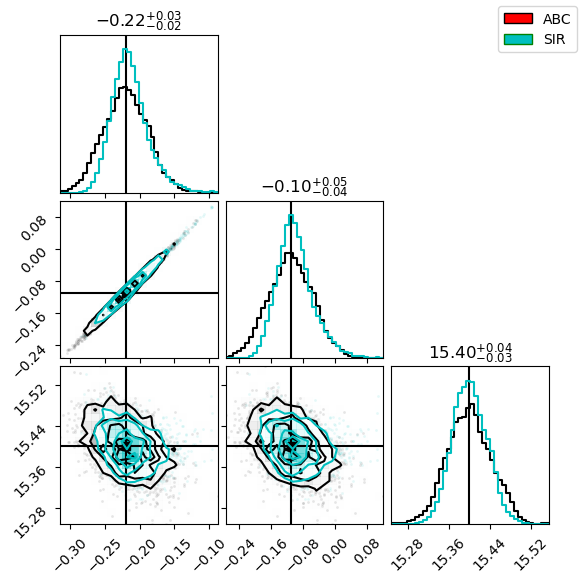

In [11]:
inverse = np.linalg.pinv(fisher)
samples = np.random.multivariate_normal(params[0][autoflag], inverse[autoflag][:, autoflag], N)

autorange = np.array([np.min(samples, axis=0), np.max(samples, axis=0)]).T
               
cfig = plt.figure(figsize=(6, 6))
corner.corner(samples, 
              color='k',
              range=autorange, fig=cfig, smooth=0.25, truths=params[0][autoflag],
              smooth1d=1.0, bins=20, hist_bin_factor=2, truth_color='k')

corner.corner(particles_sir[0].T[autoflag].T, 
              color='c',
              range=autorange, fig=cfig, smooth=0.25,
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True, alpha=0.5)
cfig.legend(handles=[
    Patch(facecolor='r', edgecolor='k', label="ABC"),
    Patch(facecolor='c', edgecolor='g', label="SIR")
], loc='upper right')
plt.show()